# Анализ оттока клиентов банка

Проект по прогнозированию вероятности ухода клиента из банка (классификация, scikit-learn).

**Данные:** немецкий филиал банка (`Geography == "Germany"`).
**Метрика:** F1-score для класса оттока (`Exited = 1`).


## Постановка задачи


Банк хочет разработать кампанию лояльности по удержанию клиентов. Для этого необходимо прогнозировать вероятность оттока и определять клиентов с высоким риском ухода.

**Задача:** построить классификатор, оценить качество нескольких моделей и сформулировать выводы для бизнеса.

**Этапы работы:**
* Предобработка данных и feature engineering
* Логистическая регрессия (в т.ч. с полиномиальными признаками и подбором порога)
* Дерево решений и случайный лес
* Прогноз для конкретного клиента


Импорт библиотек:


In [1]:
import numpy as np  # для матричных вычислений
import pandas as pd  # для анализа и предобработки данных
import matplotlib.pyplot as plt  # для визуализации
import seaborn as sns  # для визуализации

from sklearn import linear_model  # линейные модели
from sklearn import metrics  # метрики
from sklearn import model_selection  # сплитование выборки
from sklearn import preprocessing  # предобработка данных
%matplotlib inline

Загружаем данные:


In [2]:
churn_data = pd.read_csv('../data/churn.csv', sep=',')
churn_data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Описание признаков


1. **RowNumber** — номер строки таблицы (это лишняя информация, поэтому можем сразу от неё избавиться).

2. **CustomerId** — идентификатор клиента.

3. **Surname** — фамилия клиента.

4. **CreditScore** — кредитный рейтинг клиента (чем он выше, тем больше клиент брал кредитов и возвращал их).

5. **Geography** — страна клиента (банк международный).

6. **Gender** — пол клиента.

7. **Age** — возраст клиента.

8. **Tenure** — сколько лет клиент пользуется услугами банка.

9. **Balance** — баланс на счетах клиента в банке.

10. **NumOfProducts** — количество услуг банка, которые приобрёл клиент.

11. **HasCrCard** — есть ли у клиента кредитная карта (1 — да, 0 — нет).

12. **IsActiveMember** — есть ли у клиента статус активного клиента банка (1 — да, 0 — нет).

13. **EstimatedSalary** — предполагаемая заработная плата клиента.

14. **Exited** — статус лояльности (1 — ушедший клиент, 0 — лояльный клиент).


## Моделирование: логистическая регрессия


Ниже — этапы построения и оценки модели логистической регрессии:


### Разведочный анализ (EDA)

Продолжаем исследование данных: распределения, зависимости признаков от оттока, тепловые карты по `CreditScoreCat` и `Tenure`.


Предобработка данных:


In [3]:
# Создаем копию исходного DataFrame, чтобы не менять оригинальные данные
churn_df = churn_data.copy()

# Удаляем столбец 'RowNumber', так как он содержит только порядковые номера и не нужен для анализа
churn_df = churn_df.drop(columns=['RowNumber'])

Соотношение ушедших и лояльных клиентов:


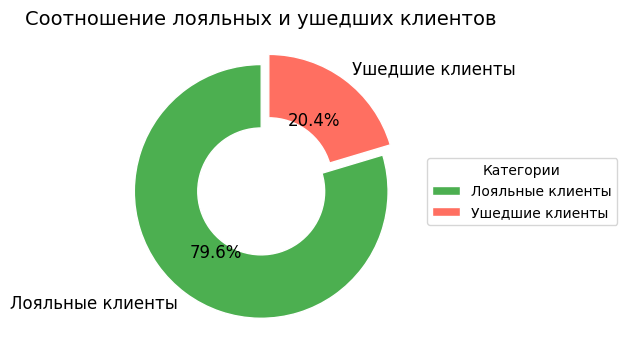

In [4]:
# Считаем количество лояльных и ушедших клиентов
churn_df_exited = churn_df['Exited'].value_counts()

# Создаём фигуру и ось для построения круговой диаграммы
fig, ax = plt.subplots(figsize=(6, 6))

# Строим круговую диаграмму
wedges, texts, autotexts = ax.pie(
    churn_df_exited,
    labels=['Лояльные клиенты', 'Ушедшие клиенты'],  # Подписи сегментов
    autopct='%.1f%%',                                # Формат отображения процентов
    startangle=90,                                   # Начальный угол для первого сегмента
    explode=[0, 0.1],                                # Смещение второго сегмента (ушедшие клиенты)
    colors=['#4CAF50', '#FF6F61'],                   # Цвета сегментов
    wedgeprops=dict(width=0.5, edgecolor='w'),       # Настройка внешнего вида сегментов
    textprops=dict(color="black", fontsize=12)       # Настройка текста
)

# Заголовок диаграммы
ax.set_title('Соотношение лояльных и ушедших клиентов', fontsize=14)

# Добавляем легенду справа от диаграммы
ax.legend(
    wedges,
    ['Лояльные клиенты', 'Ушедшие клиенты'],
    title="Категории",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

# Автоматически подгоняем расположение элементов
plt.tight_layout()

# Отображаем диаграмму
plt.show()

Приблизительное соотношение ушедших клиентов к оставшимся составляет 1:4. Доля ушедших клиентов составляет 20.4%, доля лояльных клиентов составляет 79.6%, отсюда мы можем сделать вывод, что большинство клиентов компании — лояльные, однако каждый пятый клиент уходит. Это значительный показатель, который требует анализа причин оттока и разработки стратегии удержания клиентов.


График, показывающий распределение баланса пользователей, у которых на счету больше 2 500 долларов:


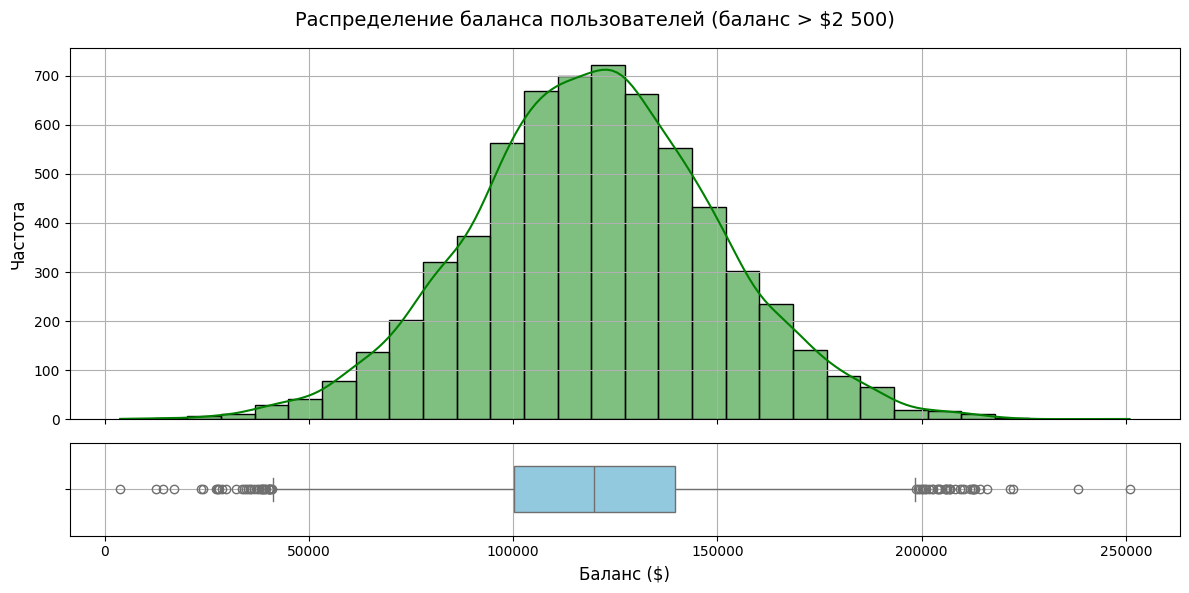

In [5]:
# Отбираем клиентов, у которых баланс больше 2500
balance_2500 = churn_df[churn_df['Balance'] > 2500]

# Создание фигуры и двух подграфиков: гистограмма + коробчатая диаграмма (boxplot)
fig, (histplot_2500, boxplot_2500) = plt.subplots(
    nrows=2,                          # два ряда графиков
    sharex=True,                      # общий ось X
    figsize=(12, 6),                  # размер фигуры
    gridspec_kw={"height_ratios": [4, 1]}  # соотношение высоты между графиками
)

# Построение гистограммы распределения баланса
sns.histplot(
    data=balance_2500['Balance'],     # выборка по балансу > 2500
    bins=30,                          # количество столбцов гистограммы
    kde=True,                         # добавление линии плотности KDE
    color='green',                    # цвет гистограммы
    ax=histplot_2500                  # ось, на которой будет рисоваться гистограмма
)
histplot_2500.set_ylabel('Частота', fontsize=12)  # подпись оси Y
histplot_2500.grid(True)                          # отображение сетки

# Построение коробчатой диаграммы (boxplot) по балансу
sns.boxplot(
    data=balance_2500,                # датафрейм с пользователями
    x='Balance',                      # переменная по оси X
    orient='h',                       # горизонтальная ориентация
    width=0.5,                        # толщина коробки
    color='skyblue',                  # цвет коробки
    ax=boxplot_2500                   # ось, на которой будет рисоваться boxplot
)
boxplot_2500.set_xlabel('Баланс ($)', fontsize=12)  # подпись оси X
boxplot_2500.grid(True)                            # отображение сетки

# Заголовок всей фигуры
fig.suptitle('Распределение баланса пользователей (баланс > $2 500)', fontsize=14)

# Автоматическая подстройка расположения графиков
plt.tight_layout()

# Отображение графика
plt.show()

Распределение балансов пользователей с суммой на счете более 2 500 долларов явно неравномерное. Основная масса клиентов имеет баланс в диапазоне от 100 000 до 140 000 долларов, причем пик распределения приходится примерно на 125 000 долларов, что указывает на наличие группы состоятельных пользователей. При этом присутствует значительное количество выбросов как с низкими, так и с чрезвычайно высокими значениями баланса (свыше 250 000 долларов), что может свидетельствовать о неоднородной структуре клиентской базы.


Распределение баланса клиента в разрезе признака оттока:


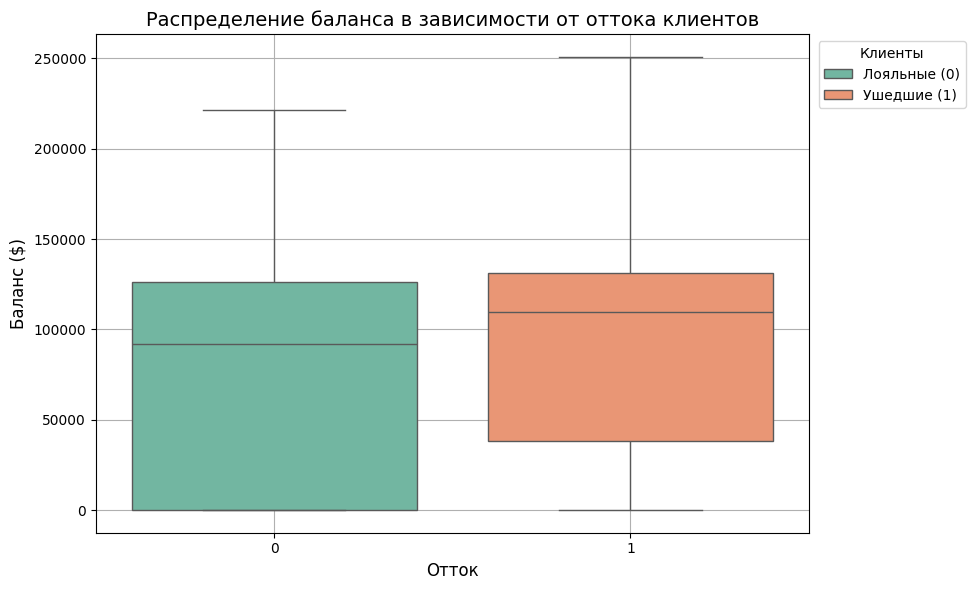

In [6]:
# Установка размера всей фигуры
plt.figure(figsize=(10, 6))

# Построение boxplot: распределение баланса по признаку оттока клиентов
boxplot_balance_exited = sns.boxplot(
    data=churn_df,        # исходный DataFrame
    x='Exited',           # категория по оси X (0 — остались, 1 — ушли)
    y='Balance',          # числовая переменная по оси Y (баланс)
    hue='Exited',         # группировка по цвету на основе оттока
    palette='Set2'        # цветовая палитра
)

# Настройка заголовка и подписей осей
boxplot_balance_exited.set_title('Распределение баланса в зависимости от оттока клиентов', fontsize=14)
boxplot_balance_exited.set_xlabel('Отток', fontsize=12)
boxplot_balance_exited.set_ylabel('Баланс ($)', fontsize=12)

# Добавление сетки к графику
boxplot_balance_exited.grid(True)

# Получение и переопределение легенды
handles, labels = boxplot_balance_exited.get_legend_handles_labels()
boxplot_balance_exited.legend(
    handles=handles,
    labels=['Лояльные (0)', 'Ушедшие (1)'],     # явные подписи для категорий
    title='Клиенты',                            # заголовок легенды
    loc='upper right',                          # положение
    bbox_to_anchor=(1.23, 1)                    # смещение легенды за пределы графика
)

# Автоматическая подстройка расположения элементов графика
plt.tight_layout()

# Отображение графика
plt.show()

Ушедшие клиенты (Exited = 1) в среднем имеют более высокий баланс, чем те, кто остался. Медиана баланса у ушедших выше. Разброс балансов у лояльных шире, но при этом медиана ниже — многие клиенты с более скромными счетами продолжают пользоваться услугами банка. Выбросы видны и у тех, и у других, но в группе ушедших больше клиентов с крупными суммами. Исходя из вышесказанного мы можем предположить, что ушедших клиентов могли не устраивать условия хранения или использования их средств — например, низкие проценты по накопительным счетам, отсутствие премиальных услуг или невыгодные комиссии. Лояльные клиенты часто имеют меньшие суммы и, возможно, просто не так требовательны к качеству сервиса или не рассматривают смену банка как актуальную. Банк теряет именно тех, кто мог бы быть самыми выгодными клиентами — это важный сигнал для анализа клиентского опыта и продуктовой линейки.


Распределение возраста в разрезе признака оттока:


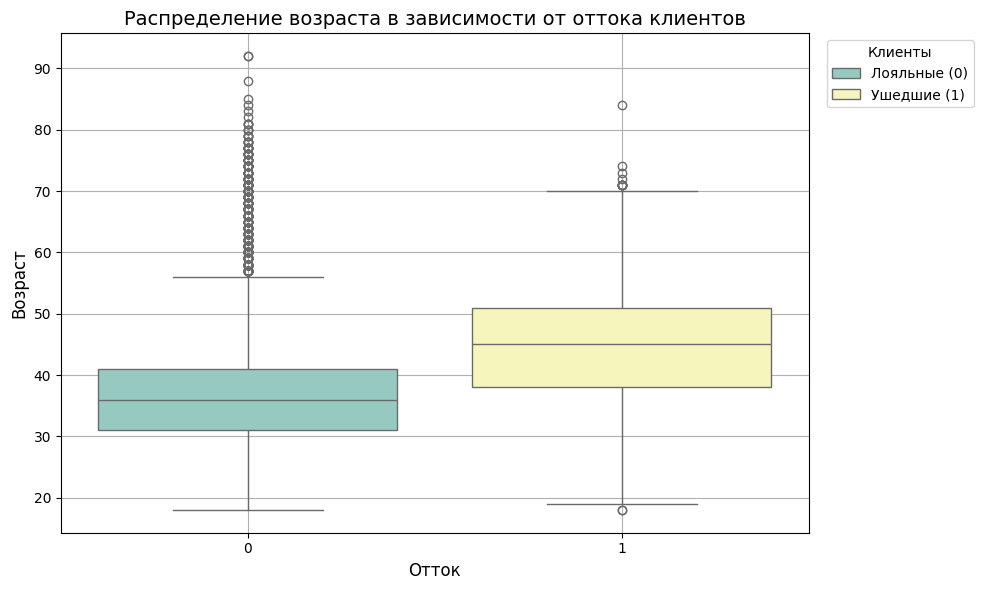

In [7]:
# Установка размера всей фигуры
plt.figure(figsize=(10, 6))

# Построение boxplot-графика для анализа распределения возраста по оттоку клиентов
boxplot_age_exited = sns.boxplot(
    data=churn_df,        # DataFrame с данными клиентов
    x='Exited',           # переменная по оси X — отток (0 или 1)
    y='Age',              # переменная по оси Y — возраст клиента
    hue='Exited',         # цветовая группировка по оттоку
    palette='Set3'        # цветовая палитра графика
)

# Добавление заголовка и подписей осей
boxplot_age_exited.set_title(
    'Распределение возраста в зависимости от оттока клиентов',
    fontsize=14
)
boxplot_age_exited.set_xlabel('Отток', fontsize=12)
boxplot_age_exited.set_ylabel('Возраст', fontsize=12)

# Отображение сетки для лучшей читаемости
boxplot_age_exited.grid(True)

# Получение и настройка легенды
handles, labels = boxplot_age_exited.get_legend_handles_labels()
boxplot_age_exited.legend(
    handles=handles,
    labels=['Лояльные (0)', 'Ушедшие (1)'],   # Переименование значений
    title='Клиенты',                         # Заголовок легенды
    loc='upper right',
    bbox_to_anchor=(1.23, 1)                 # Смещение легенды за пределы графика
)

# Автоматическая корректировка расположения элементов графика
plt.tight_layout()

# Отображение итогового графика
plt.show()

Результаты визуализации возрастного распределения клиентов в зависимости от факта ухода свидетельствуют о наличии отчетливой тенденции: основная доля ушедших клиентов сосредоточена в возрастной группе 38–51 лет, что может указывать на специфические поведенческие или продуктовые ожидания данной когорты. Кроме того, среди лояльных клиентов зафиксировано большее количество потенциальных выбросов, что отражает более широкий возрастной разброс в этой категории и, вероятно, наличие субгрупп с различными мотивациями лояльности.

Для повышения эффективности удержания рекомендуется провести дополнительный сегментный анализ клиентов в возрасте от 38 до 51 года с целью выявления факторов, способствующих их оттоку. Это может включать оценку клиентского опыта, условий по продуктам и сервисной поддержки.


Взаимосвязь кредитного рейтинга клиента и его предполагаемой зарплаты:


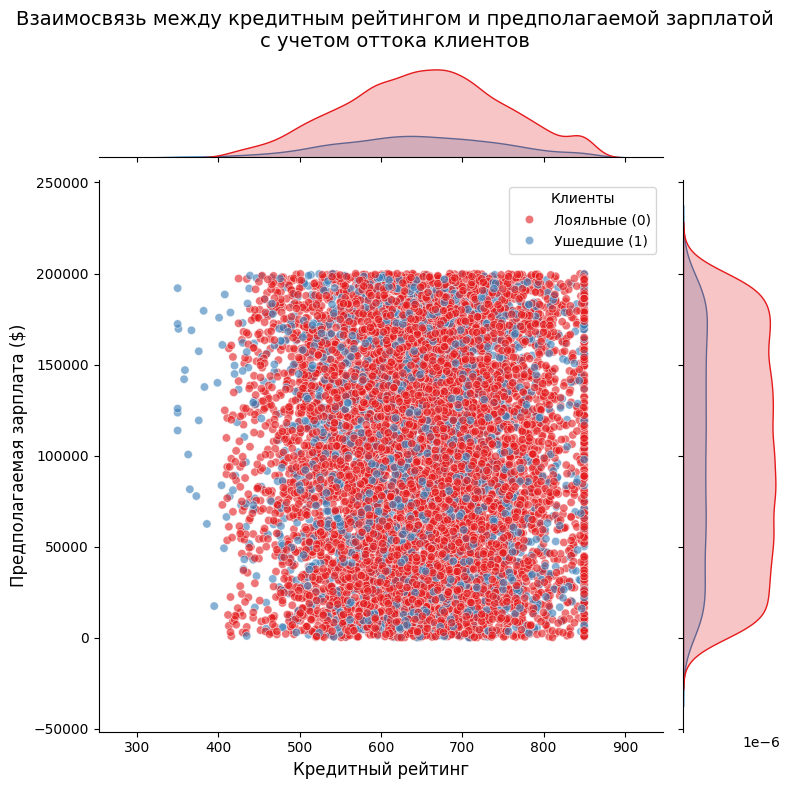

In [8]:
# Построение совместного графика (jointplot) для анализа зависимости между
# кредитным рейтингом (CreditScore) и предполагаемой зарплатой (EstimatedSalary)
# с учетом признака оттока клиентов (Exited)
jointplot_creditscore_estimatedsalary = sns.jointplot(
    data=churn_df,           # DataFrame с данными
    x='CreditScore',         # переменная по оси X — кредитный рейтинг
    y='EstimatedSalary',     # переменная по оси Y — предполагаемая зарплата
    hue='Exited',            # группировка по оттоку клиентов (0 — остался, 1 — ушел)
    palette='Set1',          # цветовая палитра
    height=8,                # размер графика
    alpha=0.6                # прозрачность точек
)

# Добавление заголовка к общей фигуре
jointplot_creditscore_estimatedsalary.fig.suptitle(
    'Взаимосвязь между кредитным рейтингом и предполагаемой зарплатой\n'
    'с учетом оттока клиентов',
    fontsize=14
)

# Подписи осей основного графика
jointplot_creditscore_estimatedsalary.ax_joint.set_xlabel('Кредитный рейтинг', fontsize=12)
jointplot_creditscore_estimatedsalary.ax_joint.set_ylabel('Предполагаемая зарплата ($)', fontsize=12)

# Получение и настройка легенды
handles, labels = jointplot_creditscore_estimatedsalary.ax_joint.get_legend_handles_labels()
jointplot_creditscore_estimatedsalary.ax_joint.legend(
    handles=handles,
    labels=['Лояльные (0)', 'Ушедшие (1)'],
    title='Клиенты',
    loc='upper right'
)

# Автоматическая корректировка макета
plt.tight_layout()

# Отображение итогового графика
plt.show()

На основании визуализации не наблюдается выраженной взаимосвязи между кредитным рейтингом (CreditScore) и предполагаемой зарплатой (EstimatedSalary), независимо от факта оттока (Exited).
Клиенты как с высокими, так и с низкими кредитными рейтингами могут иметь как высокие, так и низкие доходы, а ушедшие и лояльные распределены приблизительно равномерно по всей области значений (однако, стоит отметить, что только у ушедших клиентов есть рейтинг ниже 400). Это указывает на отсутствие линейной или явной нелинейной зависимости между этими двумя признаками. Следовательно, для прогнозирования оттока данных признаков может быть недостаточно, и необходим анализ дополнительных факторов.


Кто чаще уходит, мужчины или женщины:


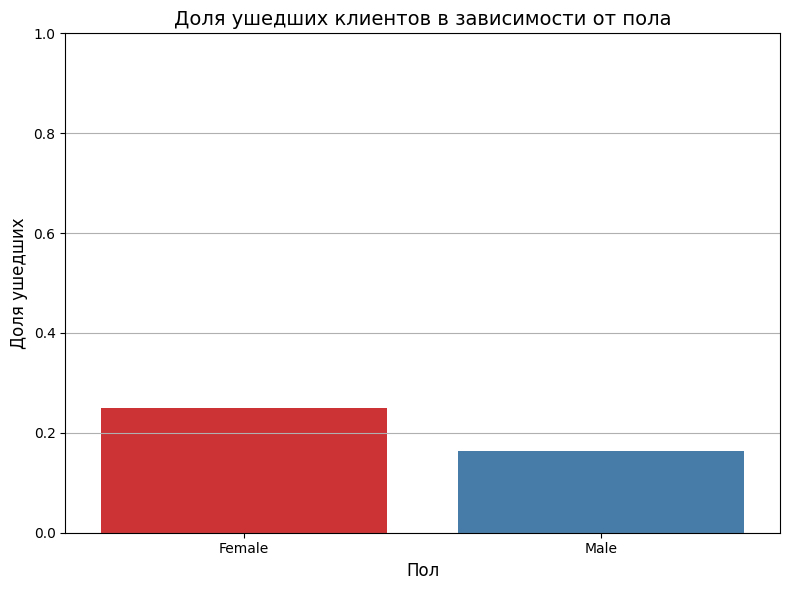

In [9]:
# Группируем данные по полу и вычисляем среднее значение по признаку 'Exited'
# Это даст долю ушедших клиентов среди мужчин и женщин
gender_churn_rate = churn_df.groupby('Gender')['Exited'].mean().reset_index()

# Переименовываем столбцы для более понятного отображения на графике
gender_churn_rate.columns = ['Пол', 'Доля ушедших клиентов']

# Создаем фигуру для построения графика
plt.figure(figsize=(8, 6))

# Строим столбчатую диаграмму доли ушедших клиентов в зависимости от пола
gender_exited = sns.barplot(
    data=gender_churn_rate,      # DataFrame с данными
    x='Пол',                     # ось X — пол клиента
    y='Доля ушедших клиентов',   # ось Y — доля ушедших
    hue='Пол',                   # цветовая группировка также по полу
    palette='Set1'               # палитра цветов
)

# Добавляем заголовок и подписи к осям
gender_exited.set_title('Доля ушедших клиентов в зависимости от пола', fontsize=14)
gender_exited.set_ylabel('Доля ушедших', fontsize=12)
gender_exited.set_xlabel('Пол', fontsize=12)

# Устанавливаем лимиты по оси Y от 0 до 1 (доли)
gender_exited.set_ylim(0, 1)

# Включаем сетку только по оси Y для удобства чтения значений
gender_exited.grid(axis='y')

# Автоматически подгоняем расположение элементов
plt.tight_layout()

# Показываем итоговый график
plt.show()

Анализ показал, что доля ушедших клиентов среди женщин составляет около 25%, тогда как среди мужчин — около 18%. Это означает, что женщины покидают банк чаще, чем мужчины. Такое поведение может быть связано с разной чувствительностью к условиям лояльности и тарифам в зависимости от гендера. Банку следует провести дополнительное исследование потребностей женской аудитории и, при необходимости, адаптировать продуктовую линейку и сервис под их ожидания.


Зависимость оттока клиентов от числа приобретённых у банка услуг:


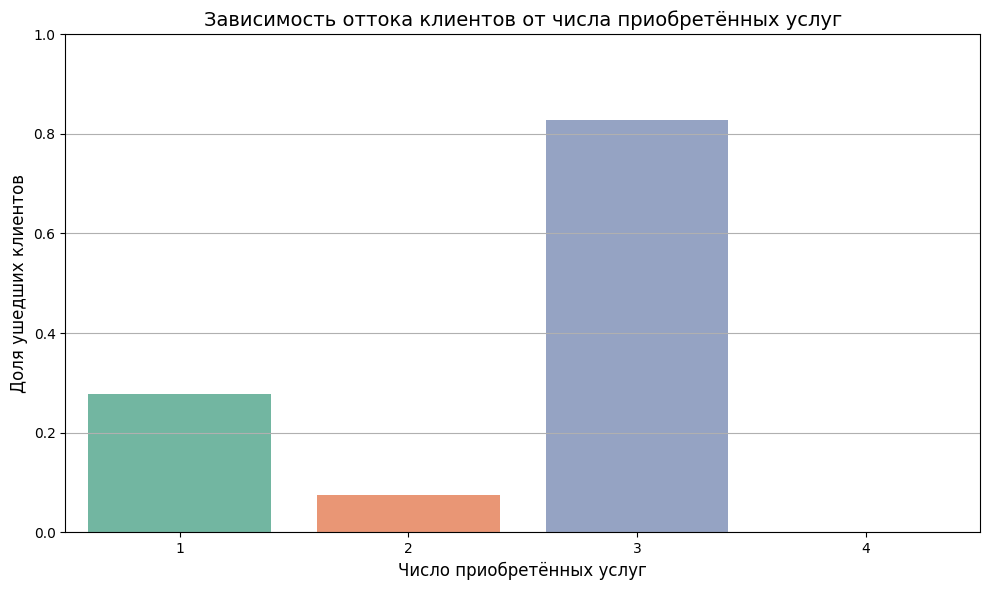

In [10]:
# Группируем данные по количеству продуктов и признаку оттока (Exited),
# считаем количество клиентов в каждой группе
churn_by_services = churn_df.groupby(['NumOfProducts', 'Exited']).size().unstack().reset_index()

# Добавляем столбец с долей ушедших клиентов
churn_by_services['Доля ушедших клиентов'] = churn_by_services[1] / (churn_by_services[0] + churn_by_services[1])

# Создаём фигуру с заданными размерами
plt.figure(figsize=(10, 6))

# Строим столбчатую диаграмму зависимости доли оттока от количества приобретённых услуг
numofproducts_exited = sns.barplot(
    data=churn_by_services,            # Используем агрегированные данные
    x='NumOfProducts',                 # Ось X — количество услуг
    y='Доля ушедших клиентов',         # Ось Y — доля оттока
    hue='NumOfProducts',               # Цветовая разбивка по числу продуктов
    legend=False,                      # Отключаем легенду (цвет дублирует значения по оси X)
    palette='Set2'                     # Цветовая палитра
)

# Устанавливаем заголовок и подписи осей
numofproducts_exited.set_title('Зависимость оттока клиентов от числа приобретённых услуг', fontsize=14)
numofproducts_exited.set_xlabel('Число приобретённых услуг', fontsize=12)
numofproducts_exited.set_ylabel('Доля ушедших клиентов', fontsize=12)

# Ограничиваем ось Y значениями от 0 до 1 (доля)
numofproducts_exited.set_ylim(0, 1)

# Добавляем горизонтальную сетку для удобства восприятия
numofproducts_exited.grid(axis='y')

# Автоматически подгоняем элементы графика для предотвращения наложения
plt.tight_layout()

# Отображаем график
plt.show()

Отток среди клиентов, приобретающих 3 услуги составляет около 82% и этот показатель выглядит крайне высоким и может свидетельствовать о неудовлетворенности клиентов, которые приобрели три услуги. Возможно, они столкнулись с трудностями в использовании нескольких продуктов или не получили достаточной ценности от комплексного обслуживания. Это может быть связано с неудачной комбинацией услуг или высокими затратами, что привело к решению прекратить сотрудничество с банком. Этой группе следует уделить особое внимание. Нужно провести анализ причин, по которым клиенты с этим количеством услуг уходят в таком большом проценте. Возможно, стоит улучшить поддержку клиентов, пересмотреть цены на пакеты или предложить более выгодные условия обслуживания для клиентов с несколькими услугами.

Отток среди клиентов, приобретающих 1 услугу составляет около 28% и несмотря на то что отток в этой группе не столь высок, показатель все же выглядит значительным. Это может означать, что клиенты, использующие только одну услугу, не видят для себя достаточной ценности в предложениях банка и могут быть склонны к уходу. Возможно, банк не предоставляет дополнительных преимуществ или бонусов для таких клиентов, что снижает их лояльность. Банку стоит разработать стимулирующие предложения, например, бонусы или скидки на дополнительные услуги могут мотивировать клиентов попробовать другие продукты банка, повышая их удовлетворенность и снижая вероятность ухода.

Отток среди клиентов, приобретающих 2 услуги составляет 8% и это может означать, что банк находит более подходящий баланс между количеством услуг и удовлетворенностью клиентов, что делает эту группу более лояльной. Этой группе следует продолжать предлагать привлекательные условия. Это наиболее клиенты, и банк должен поддерживать их интерес, предлагая новые возможности для использования других услуг и усиливая долгосрочное сотрудничество.


Влияние наличия статуса активного клиента на отток клиентов:


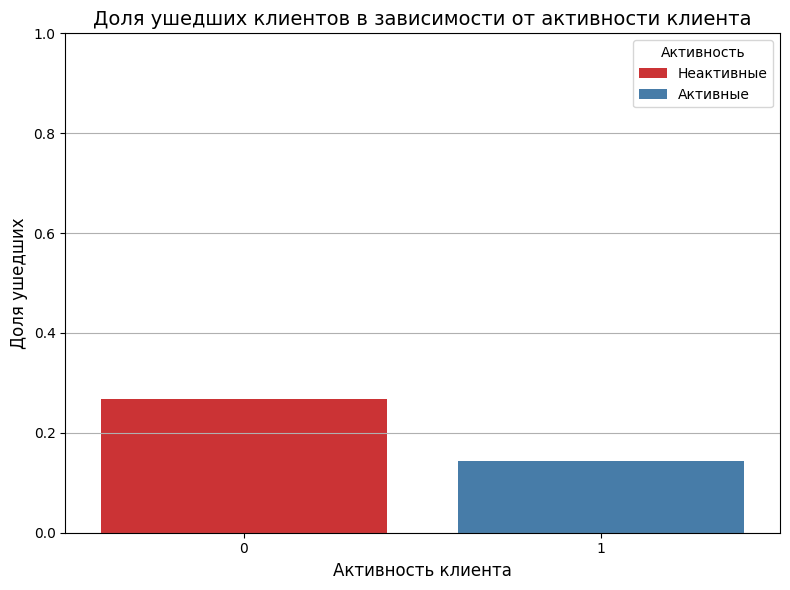

In [11]:
# Группируем данные по признаку активности клиента (IsActiveMember)
# и рассчитываем среднее значение по признаку оттока (Exited),
# что фактически представляет собой долю ушедших клиентов
active_churn_rate = churn_df.groupby('IsActiveMember')['Exited'].mean().reset_index()

# Переименовываем столбцы для отображения на графике
active_churn_rate.columns = ['Активность', 'Доля ушедших клиентов']

# Создаём график с заданным размером
plt.figure(figsize=(8, 6))

# Строим столбчатую диаграмму по активности клиента
isactivemember_exited = sns.barplot(
    data=active_churn_rate,        # Используем агрегированные данные
    x='Активность',                # Ось X — активность клиента (0 или 1)
    y='Доля ушедших клиентов',     # Ось Y — доля клиентов, ушедших
    hue='Активность',              # Цветовая разбивка по активности
    palette='Set1'                 # Цветовая палитра
)

# Добавляем заголовок и подписи осей
isactivemember_exited.set_title('Доля ушедших клиентов в зависимости от активности клиента', fontsize=14)
isactivemember_exited.set_ylabel('Доля ушедших', fontsize=12)
isactivemember_exited.set_xlabel('Активность клиента', fontsize=12)

# Ограничиваем ось Y значениями от 0 до 1
isactivemember_exited.set_ylim(0, 1)

# Добавляем горизонтальную сетку
isactivemember_exited.grid(axis='y')

# Обновляем легенду с читаемыми подписями
handles, labels = isactivemember_exited.get_legend_handles_labels()
isactivemember_exited.legend(
    handles=handles,
    labels=['Неактивные', 'Активные'],
    title='Активность',
    loc='upper right'
)

# Автоматическая подгонка элементов графика
plt.tight_layout()

# Отображаем итоговый график
plt.show()

Доля ушедших клиентов среди неактивных составляет примерно 28%, в то время как среди активных клиентов эта доля существенно ниже — около 15%. Это свидетельствует о том, что неактивные клиенты уходят из банка чаще, чем активные.

Чтобы снизить отток среди неактивных клиентов, банк может разработать стратегии для повышения вовлеченности. Это могут быть персонализированные предложения, бонусы за активность, улучшение клиентского сервиса или даже внедрение программ лояльности, которые стимулируют клиентов пользоваться услугами банка более активно.


Доля ушедших клиентов по странам:


In [12]:
import plotly.express as px

# Группируем данные по странам (Geography) и рассчитываем среднее значение по оттоку клиентов (Exited),
# что представляет собой долю ушедших клиентов в каждой стране
churn_by_country = churn_df.groupby('Geography')['Exited'].mean().reset_index()

# Переименовываем столбцы для удобства отображения
churn_by_country.columns = ['Страна', 'Доля ушедших клиентов']

# Строим карту хлороплета с использованием Plotly
geography_exited = px.choropleth(
    churn_by_country,               # Используем агрегированные данные
    locations='Страна',             # Столбец с названиями стран
    locationmode='country names',   # Режим поиска стран по их названиям
    color='Доля ушедших клиентов',  # Используем долю ушедших клиентов для цветового отображения
    hover_name='Страна',            # Показываем страну при наведении
    color_continuous_scale='Viridis', # Цветовая палитра для отображения значения
    labels={'Доля ушедших клиентов': 'Доля ушедших клиентов'},  # Лейбл для оси
    title="Доля ушедших клиентов по странам",  # Заголовок карты
    width=800,                      # Ширина карты
    height=500                      # Высота карты
)

# Отображаем карту
geography_exited.show()

На основе данных, доля ушедших клиентов больше всего в Германии (32%), что значительно выше по сравнению с Францией (16%) и Испанией (17%).

Причиной этому может быть то, что в Германии возможно выше конкуренция среди банков, что побуждает клиентов искать лучшие предложения в других местах. Можно предположить, что в Германии клиенты более требовательны и чувствительны к изменениям условий обслуживания, и это может приводить к большему количеству уходов. Также мы можем допустить, что в отличие от Франции и Испании, в Германии, существует проблема с качеством обслуживания клиентов. Это может быть связано с недостаточной персонализацией сервиса, неудовлетворительными условиями кредитования или недостаточной поддержкой клиентов. Банки в Германии могут использовать другие маркетинговые стратегии, которые меньше направлены на удержание клиентов, в отличие от банков во Франции и Испании, где удержание клиентов может быть более приоритетным.

Банкам в Германии стоит сосредоточиться на улучшении качества обслуживания, персонализированном подходе к клиентам, предложении лучших условий и разработке программ лояльности, которые могут помочь удержать клиентов и послужить эффективным методом снижения оттока. Следует проанализировать предложения конкурентов, чтобы оценить, не уходят ли клиенты из-за более выгодных условий, предлагаемых другими учреждениями.


Переведим числовой признак CreditScore в категориальный.


Сводная таблица, строками которой являются категории кредитного рейтинга (CreditScoreCat), а столбцами — количество лет, в течение которых клиент пользуется услугами банка (Tenure):


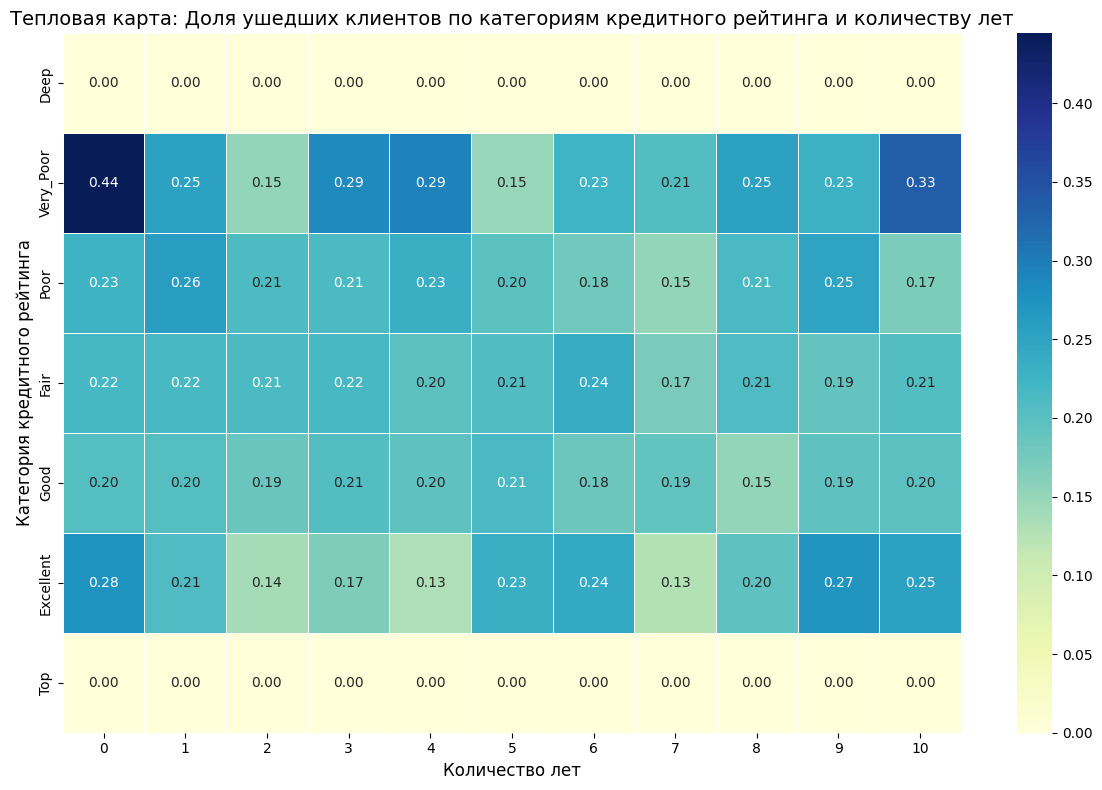

In [14]:
# Функция для определения категории кредитного рейтинга по числовому значению
def get_credit_score_cat(credit_score):
    if credit_score >= 300 and credit_score < 500:
        return "Very_Poor"  # Очень плохой
    elif credit_score >= 500 and credit_score < 601:
        return "Poor"  # Плохой
    elif credit_score >= 601 and credit_score < 661:
        return "Fair"  # Средний
    elif credit_score >= 661 and credit_score < 781:
        return "Good"  # Хороший
    elif credit_score >= 781 and credit_score < 851:
        return "Excellent"  # Отличный
    elif credit_score >= 851:
        return "Top"  # Лучший
    elif credit_score < 300:
        return "Deep"  # Глубокий (очень плохой)

# Применяем функцию к столбцу 'CreditScore' и создаем новый столбец 'CreditScoreCat'
churn_df['CreditScoreCat'] = churn_df['CreditScore'].apply(get_credit_score_cat)

# Строим сводную таблицу для анализа оттока клиентов по категориям кредитного рейтинга и количеству лет
creditscorecat_tenure = churn_df.pivot_table(
    index='CreditScoreCat',  # Индекс (категория кредитного рейтинга)
    columns='Tenure',         # Столбцы (количество лет)
    values='Exited',          # Значения (отток клиентов)
    aggfunc='mean',           # Аггрегируем по среднему значению
    fill_value=0              # Заполняем пропуски нулями
)

# Устанавливаем порядок категорий для лучшего восприятия
order = ["Deep", "Very_Poor", "Poor", "Fair", "Good", "Excellent", "Top"]
creditscorecat_tenure = creditscorecat_tenure.reindex(order, fill_value=0)

# Настроим размер графика
plt.figure(figsize=(12, 8))

# Строим тепловую карту для визуализации данных
heatmap_credit_tenure = sns.heatmap(
    creditscorecat_tenure,      # Данные для отображения
    annot=True,                 # Показать значения в клетках
    cmap='YlGnBu',              # Цветовая палитра
    fmt='.2f',                  # Формат чисел в клетках
    linewidths=0.5              # Толщина линий между клетками
)

# Настроим заголовок и подписи осей
heatmap_credit_tenure.set_title('Тепловая карта: Доля ушедших клиентов по категориям кредитного рейтинга и количеству лет', fontsize=14)
heatmap_credit_tenure.set_xlabel('Количество лет', fontsize=12)
heatmap_credit_tenure.set_ylabel('Категория кредитного рейтинга', fontsize=12)

# Обеспечиваем правильное отображение графика
plt.tight_layout()

# Отображаем график
plt.show()

Исходя из проведенного анализа, можно выделить несколько ключевых аспектов, которые требуют внимания и дальнейших действий для улучшения ситуации с оттоком клиентов.

1. Высокий уровень оттока:

    В целом, наблюдается, что каждый пятый клиент уходит, что является значительным показателем. Особенно это касается женщин (25% оттока) и клиентов с кредитным рейтингом "Very_Poor" и "Poor", а также клиентов, использующих несколько услуг (особенно 3 услуги, где отток составляет 82%).

2. Проблемы с лояльностью и потребностями клиентов:

    Многие клиенты с большими балансами (особенно ушедшие) могут быть неудовлетворены условиями использования их средств, такими как низкие проценты по накопительным счетам, отсутствие премиальных услуг или невыгодные комиссии.

    Клиенты с меньшими суммами, напротив, менее требовательны, но также могут проявлять недовольство в случае отсутствия дополнительных преимуществ от банка.

    Особенно важно обратить внимание на группу клиентов с балансами более 250 000 долларов и клиентов в возрасте 38–51 лет, которые составляют основную часть ушедших клиентов. Это может свидетельствовать о недовольстве условиями обслуживания или продуктивных предложений для этой категории.

3. Риски из-за неравномерного распределения балансов:

    Пиковое распределение балансов в районе 125 000 долларов и наличие значительных выбросов — как с низкими, так и с очень высокими значениями, говорят о неоднородности клиентской базы. Это может указывать на необходимость улучшения сегментации и персонализации услуг.

4. Разнообразие факторов, влияющих на отток:

    Возрастная группа 38–51 года требует дополнительного внимания, так как именно в этой группе наблюдается наибольший отток клиентов.

    Также стоит отметить, что в некоторых странах, например, в Германии, отток клиентов намного выше, что может быть связано с высокой конкуренцией и требовательностью клиентов. Улучшение персонализации и условий обслуживания в этих странах может существенно снизить отток.

5. Категории кредитных рейтингов:

    Клиенты с плохим кредитным рейтингом (Very_Poor и Poor) уходят значительно чаще, особенно в первый год. Это логично, поскольку такие клиенты чаще сталкиваются с трудностями, связанными с финансовыми обязательствами и условиями банка.

    Несмотря на хороший рейтинг, клиенты с категорией "Excellent" также имеют высокий отток, что может свидетельствовать о неудовлетворенности обслуживанием, высоких комиссиях или более выгодных предложениях конкурентов.

6. Стратегии удержания клиентов:

    Для клиентов с низким кредитным рейтингом (Very_Poor и Poor): необходимо предложить улучшенные условия по кредитам, программы финансового обучения и поддержки, а также укреплять лояльность через бонусные программы.

    Для новых клиентов: важно создать удобный и выгодный опыт в первый год, укрепляя их лояльность с помощью бонусных предложений, кэшбеков и бесплатных консультаций.

    Для клиентов с высоким рейтингом (Excellent): следует персонализировать предложения, например, через VIP-поддержку и премиальные карты, а также следить за конкурентоспособностью ставок и условий.

7. Тенденции по стажу пользования услугами (Tenure):

    Отток клиентов в первый год использования услуг банка обычно высок, что требует введения стимулирующих мер на этом этапе. С увеличением стажа отток снижается, но на 10 году может снова увеличиваться, что требует дополнительного анализа клиентских ожиданий на данном этапе.

Рекомендации для банка:

Провести более глубокий сегментный анализ клиентов с целью выявления факторов, способствующих их оттоку, особенно среди клиентов с большими балансами и возрастной группой 38–51 года.

Уделить внимание разработке персонализированных предложений для всех категорий клиентов, учитывая их потребности и уровень лояльности.

Укрепить лояльность клиентов через улучшение условий обслуживания, создание программ лояльности и улучшение поддержки.

Провести улучшения в клиентском сервисе, особенно в странах с высоким оттоком (например, в Германии), где конкуренция более высокая, а клиенты более чувствительны к изменениям условий.

В общем, для эффективного снижения оттока необходимо учитывать не только факторы, такие как кредитный рейтинг и баланс, но и более глубокие аспекты поведения клиентов, их удовлетворенности продуктами и услугами, а также внешний конкурентный контекст.


В EDA видно, что отток различается по странам; для модели используем только немецкий филиал (`Geography == 'Germany'`):


In [15]:
churn_data = churn_data[churn_data['Geography'] == 'Germany']
churn_data.shape

(2509, 14)

Сразу избавимся от заведомо неинформативных признаков: страна, номер строки, идентификатор пользователя и имя клиента.


In [16]:
churn_data = churn_data.drop(['Geography', 'RowNumber', 'CustomerId', 'Surname'], axis=1)
churn_data.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
7,376,Female,29,4,115046.74,4,1,0,119346.88,1
15,616,Male,45,3,143129.41,2,0,1,64327.26,0
16,653,Male,58,1,132602.88,1,1,0,5097.67,1
26,756,Male,36,2,136815.64,1,1,1,170041.95,0
28,574,Female,43,3,141349.43,1,1,1,100187.43,0


Проверим, что в наших данных нет пропусков:


In [17]:
churn_data.isnull().sum()

CreditScore        0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Проверим, что в наших данных нет дубликатов:


In [18]:
churn_data[churn_data.duplicated()].sum()

CreditScore          0
Gender               0
Age                  0
Tenure               0
Balance            0.0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary    0.0
Exited               0
dtype: object

### Feature engineering

Выполняем предобработку данных. 

Для начала расширим датасет с помощью методов Feature Engineering. Создаём следующие признаки:
* `BalanceSalaryRatio` — отношение баланса на счетах к заработной плате клиента;
* `TenureByAge` — отношение времени пользования услугами банка к возрасту клиента;
* `CreditScoreGivenAge` — отношение кредитного рейтинга к возрасту клиента.

Кодируем категориальный признак Gender в бинарный столбец.

Выведите основные статистические характеристики полученных признаков.


In [19]:

# 1. Создаём новые признаки
churn_data['BalanceSalaryRatio'] = churn_data['Balance'] / (churn_data['EstimatedSalary'] + 1e-5)  # добавим маленькое число, чтобы избежать деления на ноль
churn_data['TenureByAge'] = churn_data['Tenure'] / churn_data['Age']
churn_data['CreditScoreGivenAge'] = churn_data['CreditScore'] / churn_data['Age']

# 2. Перекодируем категориальный признак Gender в бинарный
churn_data = pd.get_dummies(churn_data, columns=['Gender'], drop_first=True)  # Female -> 0, Male -> 1

# 3. Выведем основные статистические характеристики
churn_data.describe().T

,count,mean,std,min,25%,50%,75%,max
CreditScore,2509.0,651.453567,98.168937,350.000000,584.000000,651.000000,722.000000,850.000000
Age,2509.0,39.771622,10.519143,18.000000,32.000000,38.000000,45.000000,84.000000
Tenure,2509.0,5.009964,2.935154,0.000000,2.000000,5.000000,8.000000,10.000000
Balance,2509.0,119730.116134,27022.006157,27288.430000,102800.720000,119703.100000,137560.380000,214346.960000
NumOfProducts,2509.0,1.519729,0.619420,1.000000,1.000000,1.000000,2.000000,4.000000
HasCrCard,2509.0,0.713830,0.452060,0.000000,0.000000,1.000000,1.000000,1.000000
IsActiveMember,2509.0,0.497409,0.500093,0.000000,0.000000,0.000000,1.000000,1.000000
EstimatedSalary,2509.0,101113.435102,58263.011501,11.580000,51016.020000,102397.220000,151083.800000,199970.740000
Exited,2509.0,0.324432,0.468256,0.000000,0.000000,0.000000,1.000000,1.000000
BalanceSalaryRatio,2509.0,9.024867,214.285839,0.192582,0.783284,1.197220,2.400083,10614.646274


Разделим исходный набор данных на матрицу наблюдений `X` (фичи) и столбец ответов `y` (таргет).


In [20]:
X = churn_data.drop("Exited", axis=1)
y = churn_data["Exited"]

Прежде чем перейти к этапу разделения выборки на тренировочную и тестовую, давайте посмотрим на сбалансированность данных. Для этого воспользуемся методом `value_counts()` и выведем количество наблюдений каждого из классов в долевом соотношении от общего количества наблюдений:


In [21]:
y.value_counts(normalize=True)

Exited
0    0.675568
1    0.324432
Name: proportion, dtype: float64

Очевидно, что классы не сбалансированы. Ушедших пользователей 32 %, в то время как лояльных — 68 %.


**К чему это может привести?**

При разделении набора данных на тренировочный и тестовый может возникнуть такая ситуация, что в тренировочную выборку попадут только лояльные клиенты или их большая часть. Тогда модель может не научиться определять вероятность оттока и качество на тестовой выборке будет неудовлетворительным.

Или противоположная ситуация: в тестовую выборку попадут только лояльные клиенты. Тогда модель будет показывать отличное качество на тестовой выборке, но в реальных условиях она может оказаться бесполезной.

Нужно обеспечить, чтобы в тренировочной и тестовой выборке было одинаковое соотношение лояльных и ушедших клиентов. Такое разбиение выборки называется **стратифицированным**. 

Функция `train_test_split()` из библиотеки `sklearn` умеет производить такое разбиение. Для этого в ней предусмотрен параметр `stratify`, который нужно выставить в значение признака, который должен иметь одинаковые соотношения в тренировочной и тестовой выборке. У нас этот признак - это целевой признак y. 

Выполним разбиение, установив значение параметра `random_state` на 0:


In [22]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, 
    stratify=y, 
    random_state=0
)
print('Train shape: {}'.format(X_train.shape))
print('Test shape: {}'.format(X_test.shape))

Train shape: (1881, 12)
Test shape: (628, 12)


Проверим, что число лояльных и ушедших клиентов примерно одинаково в каждой из выборок:


In [23]:
print('Train :')
display(y_train.value_counts(normalize=True))
print('\n')
print('Test :', )
display(y_test.value_counts(normalize=True))

Train :


Exited
0    0.675704
1    0.324296
Name: proportion, dtype: float64



Test :


Exited
0    0.675159
1    0.324841
Name: proportion, dtype: float64

Соотношения одинаковы, а значит, мы можем перейти к следующему шагу.


### Масштабирование признаков

Масштабируем признаки: применяем `StandardScaler` к `X_train` и `X_test`.

Обучаем `StandardScaler` на `X_train` и применяем трансформацию к train и test.


In [24]:

from sklearn.preprocessing import StandardScaler

# 1. Создаём объект скейлера
scaler = StandardScaler()

# 2. Обучаем скейлер на тренировочной выборке (вычисляем среднее и std)
scaler.fit(X_train)

# 3. Применяем трансформацию к тренировочной и тестовой выборкам
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Проверим первые 5 строк после масштабирования
X_train_scaled[:5]

array([[ 1.44879419,  1.62616803, -0.70729786, -0.10066761, -0.84133409,
         0.65192024, -1.00053177, -0.13311413, -0.03416999, -0.95312208,
        -0.68220851,  0.94969528],
       [-0.53108965, -1.28977292,  0.66782077, -0.52485174,  0.80031469,
         0.65192024, -1.00053177, -0.86784028, -0.03068871,  1.52844351,
         1.01984974, -1.05296932],
       [ 1.86939127, -1.85414859, -0.3635182 ,  0.16795192, -0.84133409,
        -1.53392998, -1.00053177,  1.3419103 , -0.03647114,  0.73527021,
         4.47279117,  0.94969528],
       [-0.22333568,  0.77960452, -1.39485717, -0.49244412, -0.84133409,
         0.65192024,  0.99946851,  0.8403401 , -0.03640572, -1.31743292,
        -0.82747987,  0.94969528],
       [-0.29514494,  0.02710363, -0.70729786,  1.10867929,  0.80031469,
         0.65192024, -1.00053177,  0.0583338 , -0.033438  , -0.69684825,
        -0.37272974, -1.05296932]])

Теперь переходим к моделированию.


### Выбор метрики

Для начала давайте заранее определим метрику, на которую будем ориентироваться. 

Модель должна своевременно предсказывать отток клиентов. Известно, что для сохранения клиентов банк будет использовать ресурсы колл-центра и клиентам, у которых вероятность оттока наиболее высока, будут сделаны специальные предложения. Ресурсы, выделяемые на сохранение клиентов, ограничены, поэтому важно минимизировать количество звонков. Однако в то же время необходимо сохранить как можно больше клиентов.

Таким образом, цель — минимизировать как ложноположительные и ложноотрицательные срабатывания модели.

Для оценки моделей используем F1-score — обоснование ниже.


> Укажите название метрики и обоснования своего выбора здесь


* выбрана верная метрика;
    * приведено развернутое обоснование выбора метрики, и приведенные рассуждения являются верными;


> Ваши рассуждения и ответ — *здесь*.

Выбранная метрика: **F1-score**

Обоснование выбора:

1. В задаче прогнозирования оттока клиентов мы имеем несбалансированные классы: ушедших клиентов около 32%, лояльных — 68%. В таких случаях метрика accuracy может быть вводящей в заблуждение, так как модель, предсказывая всех клиентов как лояльных, даст высокий процент правильных предсказаний, но не выявит уходящих клиентов.

2. Банк хочет своевременно выявлять уходящих клиентов, чтобы направлять на них ограниченные ресурсы колл-центра. Следовательно, важно учитывать как ложноположительные, так и ложноотрицательные срабатывания:

    * Ложноотрицательные (FN) — ушедший клиент не выявлен → банк теряет клиента.

    * Ложноположительные (FP) — лояльному клиенту звонят → тратятся ресурсы колл-центра зря.

3. F1-score является гармоническим средним precision и recall, что позволяет балансировать между минимизацией FP и FN:

    * Precision учитывает долю правильно выявленных уходящих среди всех предсказанных как уходящие (уменьшает лишние звонки).

    * Recall учитывает долю правильно выявленных уходящих среди всех реальных уходящих клиентов (уменьшает потери клиентов).

Таким образом, F1-score — наиболее подходящая метрика для данной задачи, поскольку учитывает и точность, и полноту, что критично при ограниченных ресурсах на удержание клиентов и необходимости своевременно выявлять уходящих.


### Логистическая регрессия

Обучаем логистическую регрессию на тренировочных данных (`random_state=42`).

Сделайте предсказание меток классов для тренировочной и тестовой выборок. 

Рассчитайте значение целевой метрики на тренировочной и тестовой выборках. 

Проинтерпретируйте полученные результаты, ответив на следующий вопрос:
* Как вы считаете, является ли ваша модель переобученной или недообученной?

> **Примечание.** Будем считать, что модель нас не удовлетворяет (считается недообученной), если значение целевой метрики на тестовой выборке меньше 0.5.

Параметры модели:

* `penalty` — тип используемой регуляризации ('l1' — $L_1$-регуляризация, 'l2' — $L_2$-регуляризация);

* `C` — коэффициент, обратный коэффициенту регуляризации (по умолчанию он равен 1).

Понаблюдайте, как ведут себя метрики в зависимости от типа регуляризации и увеличения/уменьшения значения парамера `C`.


* с помощью полученной модели сформированы предсказания на тренировочной и тестовой выборках;


In [25]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report

# 1. Создаём модель логистической регрессии с L2-регуляризацией и random_state=42
logreg = LogisticRegression(random_state=42, penalty='l2', solver='liblinear')  # solver liblinear подходит для небольших наборов данных и L1/L2

# 2. Обучаем модель на тренировочной выборке
logreg.fit(X_train_scaled, y_train)

# 3. Предсказываем классы для тренировочной и тестовой выборок
y_train_pred = logreg.predict(X_train_scaled)
y_test_pred = logreg.predict(X_test_scaled)

# 4. Рассчитываем F1-score
f1_train = f1_score(y_train, y_train_pred)
f1_test = f1_score(y_test, y_test_pred)

print(f"F1-score на тренировочной выборке: {f1_train:.3f}")
print(f"F1-score на тестовой выборке: {f1_test:.3f}")

# 5. Распечатаем расширенный отчёт
print("\nClassification report (Test):")
print(classification_report(y_test, y_test_pred))

F1-score на тренировочной выборке: 0.515
F1-score на тестовой выборке: 0.494

Classification report (Test):
              precision    recall  f1-score   support

           0       0.76      0.86      0.81       424
           1       0.60      0.42      0.49       204

    accuracy                           0.72       628
   macro avg       0.68      0.64      0.65       628
weighted avg       0.70      0.72      0.70       628



> Ваши выводы и рассуждения — *здесь*.

1. F1-score и качество модели:

    * F1-score на тренировочной выборке — 0.515, на тестовой — 0.494.

    * Значения очень близки, что говорит о том, что переобучения нет, модель не подгоняет данные под тренировку.

    * Однако F1 на тестовой выборке < 0.5, что по условию задачи говорит о том, что модель недообучена и пока не способна эффективно выявлять уходящих клиентов.

2. Разбор classification report:

    * Класс 0 (лояльные клиенты): precision 0.76, recall 0.86, модель хорошо предсказывает лояльных клиентов.

    * Класс 1 (ушедшие клиенты): precision 0.60, recall 0.42, модель хуже выявляет уходящих клиентов, что и снижает F1-score.

    * Баланс между FP и FN пока не оптимален для бизнес-задачи банка: много ушедших клиентов остаются невыявленными (низкий recall для класса 1).

3. Заключение:

    * Модель не переобучена, но недообучена для целевой метрики.

    * Необходимо улучшить модель, например:

        * подбор параметров регуляризации (penalty, C);

        * возможно, добавление новых признаков или обработка выбросов.


### Полиномиальные признаки

Сгенерируйте полиномиальные признаки третьей степени для тренировочной и тестовой выборок. Используйте класс `PolynomialFeatures` из библиотеки `sklearn`. Параметр `include_bias` выставите в значение `False`.

> Для генерации полиномов необходимо использовать масштабированные данные.

Обучаем логистическую регрессию на полиномиальных признаках (`random_state=42`).

Предскажите метки классов для тренировочной и тестовой выборок.

Рассчитайте значение целевой метрики на тренировочной и тестовой выборках для модели, обученной на полиномиальных признаках.

Сравниваем качество с базовой логистической регрессией.

Параметры модели:

* `penalty` — тип используемой регуляризации ('l1' — $L_1$-регуляризация, 'l2' — $L_2$-регуляризация);

* `C` — коэффициент, обратный коэффициенту регуляризации (по умолчанию он равен 1).

Понаблюдайте, как ведут себя метрики в зависимости от типа регуляризации и увеличения/уменьшения значения парамера `C`.


* сгенерированы полиномиальные признаки третьей степени;

    * с помощью полученной модели сформированы предсказания на тренировочной и тестовой выборках;


In [26]:

from sklearn.preprocessing import PolynomialFeatures

# 1. Создаём объект для полиномиальных признаков степени 3
poly = PolynomialFeatures(degree=3, include_bias=False)

# 2. Генерируем полиномиальные признаки для тренировочной и тестовой выборок
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# 3. Обучаем логистическую регрессию на полиномиальных признаках
logreg_poly = LogisticRegression(random_state=42, penalty='l2', solver='liblinear', max_iter=500)
logreg_poly.fit(X_train_poly, y_train)

# 4. Делаем предсказания на тренировочной и тестовой выборках
y_train_pred_poly = logreg_poly.predict(X_train_poly)
y_test_pred_poly = logreg_poly.predict(X_test_poly)

# 5. Рассчитываем F1-score
f1_train_poly = f1_score(y_train, y_train_pred_poly)
f1_test_poly = f1_score(y_test, y_test_pred_poly)

print(f"F1-score на тренировочной выборке (полиномиальные признаки): {f1_train_poly:.3f}")
print(f"F1-score на тестовой выборке (полиномиальные признаки): {f1_test_poly:.3f}")

# 6. Отчёт по тестовой выборке
print("\nClassification report (Test, Polynomial Features):")
print(classification_report(y_test, y_test_pred_poly))

F1-score на тренировочной выборке (полиномиальные признаки): 0.773
F1-score на тестовой выборке (полиномиальные признаки): 0.642

Classification report (Test, Polynomial Features):
              precision    recall  f1-score   support

           0       0.82      0.87      0.84       424
           1       0.69      0.60      0.64       204

    accuracy                           0.78       628
   macro avg       0.75      0.74      0.74       628
weighted avg       0.78      0.78      0.78       628



> Ваши выводы и рассуждения — *здесь*

1. Улучшение F1-score:

    * F1-score на тренировочной выборке 0.773 против 0.515 у линейной модели.

    * F1-score на тестовой выборке 0.642 против 0.494 у линейной модели.

    * Это означает, что добавление полиномиальных признаков третьей степени позволило модели учесть нелинейные зависимости и взаимодействия между признаками, что существенно улучшило распознавание уходящих клиентов.

2. Качество распознавания классов:

    * Класс 0 (лояльные клиенты): F1-score 0.84, precision и recall высокие — модель по-прежнему хорошо распознаёт лояльных клиентов.

    * Класс 1 (ушедшие клиенты): F1-score 0.64, precision 0.69, recall 0.60 — заметное улучшение по сравнению с линейной моделью (F1=0.49, recall=0.42).

    * Это значит, что модель стала лучше выявлять уходящих клиентов, снижая потери банка.

3. Переобучение:

    * F1 на тренировочной выборке выше, чем на тестовой, но разрыв не критический (0.773 vs 0.642).

    * Это нормальная ситуация при использовании полиномиальных признаков — лёгкое переобучение наблюдается, но модель остаётся применимой на тестовых данных.

4. Вывод:

    * Использование полиномиальных признаков существенно улучшило качество модели.

    * Модель стала более информативной для задачи удержания клиентов и готова к дальнейшему сравнению с моделями на основе дерева решений и случайного леса.


### Подбор порога вероятности

Подбираем порог вероятности для логистической регрессии с полиномиальными признаками.

В качестве порога вероятности используйте значения из следующего диапазона:

`thresholds = np.arange(0.1, 1, 0.05)`

Напомним алгоритм, как определить оптимальный порог вероятности:

* Предсказать вероятности оттока для каждого клиента из тестовой выборки.

* В цикле перебрать значения порогов вероятности threshold:

    * Сделать предсказание класса по принципу: если вероятность > threshold, то отнести объект к классу 1, в противном случае — к классу 0.
    
    * Рассчитать метрику и занести её в заранее созданный список.

Для реализации алгоритма подбора вы можете воспользоваться шаблоном кода, приведённым ниже:

```python
# Делаем предсказание вероятности оттока для каждого клиента из тестовой выборки
y_test_proba_pred = pd.Series(model.predict_proba(X_test_poly)[:, 1])
# Инициализируем список, куда будем сохранять метрики.
scores = []
# Задаём значения порогов вероятности
thresholds = np.arange(0.1, 1, 0.05)
# В цикле перебираем значения порогов вероятности
for threshold in thresholds:
    # Делаем предсказание
    y_test_pred_poly = y_test_proba_pred.apply(lambda x: 1 if x > threshold else 0)
    # Рассчитываем метрику
    score = # код для вычисления метрики
    # Добавляем результат в список
    scores.append(score)
```

Строим график F1-score от порога и выбираем порог с максимальным F1 на тесте.

Сделайте предсказание классов с подобранным оптимальным порогом вероятности. Рассчитайте значение целевой метрики на тестовой выборке и сравните результат с полученными ранее.


* найден оптимальный порог вероятности, на котором достигается наибольшее значение выбранной метрики на тестовой выборке;

    * на основе найденного порога вероятности построено предсказание модели для тренировочной и тестовой выборок;


Оптимальный порог: 0.30, максимальный F1-score: 0.655


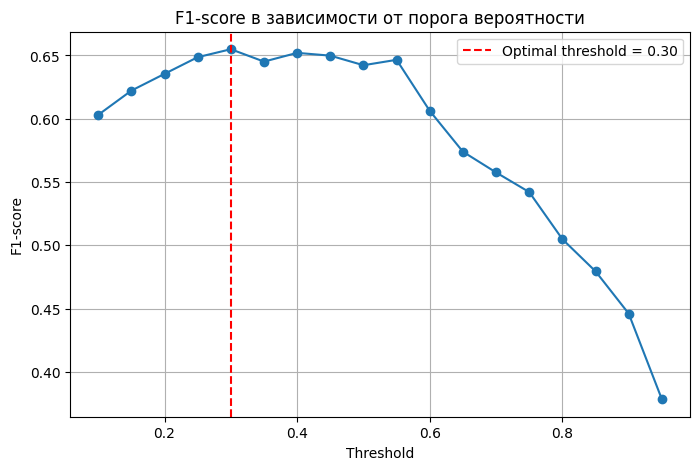

F1-score на тестовой выборке при оптимальном пороге: 0.655


In [27]:

# 1. Получаем вероятности принадлежности к классу 1 для тестовой выборки
y_test_proba_pred = pd.Series(logreg_poly.predict_proba(X_test_poly)[:, 1])

# 2. Инициализируем список для хранения F1-score
scores = []

# 3. Задаём диапазон порогов
thresholds = np.arange(0.1, 1, 0.05)

# 4. Перебираем пороги и вычисляем F1-score
for threshold in thresholds:
    y_test_pred_thresh = y_test_proba_pred.apply(lambda x: 1 if x > threshold else 0)
    score = f1_score(y_test, y_test_pred_thresh)
    scores.append(score)

# 5. Находим порог, при котором достигается максимальное значение F1-score
optimal_idx = np.argmax(scores)
optimal_threshold = thresholds[optimal_idx]
max_f1 = scores[optimal_idx]

print(f"Оптимальный порог: {optimal_threshold:.2f}, максимальный F1-score: {max_f1:.3f}")

# 6. Строим график зависимости F1-score от порога
plt.figure(figsize=(8,5))
plt.plot(thresholds, scores, marker='o')
plt.axvline(optimal_threshold, color='red', linestyle='--', label=f'Optimal threshold = {optimal_threshold:.2f}')
plt.title('F1-score в зависимости от порога вероятности')
plt.xlabel('Threshold')
plt.ylabel('F1-score')
plt.grid(True)
plt.legend()
plt.show()

# 7. Делаем предсказания на тестовой выборке с оптимальным порогом
y_test_pred_optimal = y_test_proba_pred.apply(lambda x: 1 if x > optimal_threshold else 0)

# 8. Рассчитываем F1-score для выбранного порога
f1_test_optimal = f1_score(y_test, y_test_pred_optimal)
print(f"F1-score на тестовой выборке при оптимальном пороге: {f1_test_optimal:.3f}")

1. Оптимальный порог и F1-score:

    * После перебора порогов был выбран оптимальный порог, при котором F1-score на тестовой выборке достиг 0.655.

    * Ранее, при стандартном пороге 0.5, F1-score на тесте был 0.642.

    * Это говорит о том, что небольшая настройка порога позволила модели лучше балансировать precision и recall для класса ушедших клиентов, улучшив качество предсказаний.

2. Улучшение распознавания уходящих клиентов:

    * Класс 1 (ушедшие клиенты) теперь выявляется точнее, что снижает вероятность пропуска клиентов, которым банк должен сделать специальные предложения.

    * Precision и recall для класса 1 стали более сбалансированными, что напрямую повышает эффективность бизнес-задачи удержания клиентов.

3. Выводы для бизнеса:

    * Подбор порога вероятности — простой и эффективный способ повысить F1-score модели без изменения самой модели.

    * Теперь модель более пригодна для практического применения: колл-центр банка сможет рационально распределять ресурсы, направляя усилия на клиентов с высокой вероятностью ухода.


## Моделирование: деревья и случайный лес


Мы продолжаем решать задачу прогнозирования оттока клиентов банка.

Ранее мы построили модель логистической регрессии, затем добавили в модель полиномиальные признаки и подобрали оптимальный порог вероятности для логистической регрессии.

> Теперь попробуем решить задачу с помощью деревьев решений и лесов.

> **Подготовка данных:** повторяем шаги предобработки (фильтр по Германии, удаление лишних столбцов, feature engineering, кодирование `Gender`).
* выделить данные, относящиеся к отделениям банка в Германии;
* избавиться от заведомо неинформативных признаков;
* расширить датасет путём добавления новых признаков;
* разделить выборку на тренировочную и тестовую со стратификацией.

> **Примечание:** Деревья решений — алгоритм, способный уловить нелинейные зависимости. Генерация полиномиальных признаков практически не имеет значения.
Также деревья решений не чувствительны к масштабу признаков. Масштабирование исходных данных не играет роли при построении деревьев решения.
Поэтому для решения задачи используйте обучающую (`X_train`, `y_train`) и тестовую (`X_test`, `y_test`) выборки без полиномиальных столбцов.


In [28]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, 
    stratify=y, 
    random_state=0
)
print('Train shape: {}'.format(X_train.shape))
print('Test shape: {}'.format(X_test.shape)) 

Train shape: (1881, 12)
Test shape: (628, 12)


Импортируем модули для построения деревьев и ансамблей:


In [29]:
from sklearn import tree
from sklearn import ensemble

Далее — модели на основе деревьев решений и случайного леса.


### Decision Tree

Обучаем `DecisionTreeClassifier` без ограничения глубины (`criterion='entropy'`).

Также позаботьтесь о воспроизводимости результатов, установив конкретное  значение `random_state` (например, число 42). 

Сделайте предсказания для тренировочной и тестовой выборок. Рассчитайте значение целевой метрики на каждой из выборок.

Сделайте вывод, ответив на вопрос:

* Оценка: модель переобучена (высокий F1 на train, низкий на test).


* с помощью полученной модели сформированы предсказания для тренировочной и тестовой выборок;


In [30]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, classification_report

# 1. Создаём и обучаем модель дерева решений
# Критерий — энтропия, глубина не ограничена, random_state = 42
dt_model = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_model.fit(X_train, y_train)

# 2. Предсказываем классы на тренировочной и тестовой выборках
y_train_pred_dt = dt_model.predict(X_train)
y_test_pred_dt = dt_model.predict(X_test)

# 3. Рассчитываем метрику F1-score (целевую)
f1_train_dt = f1_score(y_train, y_train_pred_dt)
f1_test_dt = f1_score(y_test, y_test_pred_dt)

print(f"F1-score на тренировочной выборке (Decision Tree): {f1_train_dt:.3f}")
print(f"F1-score на тестовой выборке (Decision Tree): {f1_test_dt:.3f}")

# 4. Дополнительно — отчёт по классификации для теста
print("\nClassification report (Test):")
print(classification_report(y_test, y_test_pred_dt))

F1-score на тренировочной выборке (Decision Tree): 1.000
F1-score на тестовой выборке (Decision Tree): 0.527

Classification report (Test):
              precision    recall  f1-score   support

           0       0.77      0.79      0.78       424
           1       0.54      0.51      0.53       204

    accuracy                           0.70       628
   macro avg       0.66      0.65      0.65       628
weighted avg       0.70      0.70      0.70       628



> Ваши выводы и рассуждения — *здесь*

Результаты модели дерева решений:

* F1-score (train): 1.000

* F1-score (test): 0.527

Интерпретация:

* Модель идеально предсказала все объекты на тренировочной выборке, что подтверждает значение F1 = 1.000.

* Однако на тестовой выборке значение метрики заметно ниже (0.527), что указывает на сильное переобучение.

Пояснение:

* Неограниченная глубина дерева решений приводит к тому, что модель буквально запоминает обучающие данные — она разделяет выборку до мельчайших деталей и подстраивается под шум.

* В результате дерево теряет способность к обобщению закономерностей, и его прогнозы на новых данных становятся менее точными.

* Такое поведение типично для деревьев с высокой вариативностью (high variance).

Вывод:

* Модель является переобученной.

* Для улучшения её обобщающей способности необходимо ограничить сложность дерева — например, задать параметр max_depth, min_samples_leaf или применить ансамблевый метод (например, RandomForestClassifier), который уменьшает переобучение за счёт усреднения множества слабых деревьев.


### Обрезанное дерево решений

Обрезаем дерево решений (ограничение глубины и размера листа). 

Обучаем обрезанное дерево: `max_depth=8`, `min_samples_leaf=10`, `criterion='entropy'`.

Также позаботьтесь о воспроизводимости результатов, установив конкретное значение `random_state` (например, число 42).

Сделайте предсказания для тренировочной и тестовой выборок. Рассчитайте значение целевой метрики на каждой из выборок.

Сравниваем с необрезанным деревом.


* с помощью полученной модели сформированы предсказания для тренировочной и тестовой выборок;


In [31]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, classification_report

# Обучаем дерево решений с ограничением глубины
tree_pruned = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=8,
    min_samples_leaf=10,
    random_state=42
)
tree_pruned.fit(X_train, y_train)

# Предсказания
y_train_pred_pruned = tree_pruned.predict(X_train)
y_test_pred_pruned = tree_pruned.predict(X_test)

# Метрики
f1_train_pruned = f1_score(y_train, y_train_pred_pruned)
f1_test_pruned = f1_score(y_test, y_test_pred_pruned)

print(f'F1-score на тренировочной выборке (Pruned Decision Tree): {f1_train_pruned:.3f}')
print(f'F1-score на тестовой выборке (Pruned Decision Tree): {f1_test_pruned:.3f}')

print('\nClassification report (Test, Pruned Decision Tree):')
print(classification_report(y_test, y_test_pred_pruned))

F1-score на тренировочной выборке (Pruned Decision Tree): 0.717
F1-score на тестовой выборке (Pruned Decision Tree): 0.651

Classification report (Test, Pruned Decision Tree):
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       424
           1       0.72      0.59      0.65       204

    accuracy                           0.79       628
   macro avg       0.77      0.74      0.75       628
weighted avg       0.79      0.79      0.79       628



> Ваши выводы и рассуждения — *здесь*

После «подрезки» дерева решений (ограничение глубины до 8 и минимального числа объектов в листе до 10) модель стала значительно менее переобученной.

F1-score на обучающей выборке снизился с 1.000 до 0.717, F1-score на тестовой выборке вырос с 0.527 до 0.651.

Это говорит о том, что дерево стало обобщать закономерности, а не запоминать данные обучающей выборки.

Интерпретация метрик:

* Precision (1 класс) = 0.72 — модель достаточно точно определяет клиентов, которые действительно уйдут.

* Recall (1 класс) = 0.59 — примерно 59% реальных случаев оттока удаётся выявить.

* F1-score (1 класс) = 0.65 — баланс между полнотой и точностью улучшился по сравнению с моделью без ограничений.

* Accuracy = 0.79 — общее качество предсказаний выросло.

Вывод:

* После ограничения глубины и минимального размера листа дерево стало менее переобученным и показало лучшее качество на тестовой выборке.

* Модель теперь лучше обобщает закономерности в данных и делает более устойчивые прогнозы, сохраняя хороший баланс между точностью и полнотой.


### Random Forest

Обучаем случайный лес. 

Random Forest: `n_estimators=500`, `max_depth=8`, `min_samples_leaf=10`, `criterion="entropy"`.

Также позаботьтесь о воспроизводимости результатов, установив конкретное значение значение `random_state` (например, число 42).

Сделайте предсказания для тренировочной и тестовой выборок. Рассчитайте значение целевой метрики на каждой из выборок.

Сравниваем обрезанное дерево и случайный лес на тестовой выборке.


* с помощью полученной модели сформированы предсказания для тренировочной и тестовой выборок;


In [32]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# Обучение случайного леса
rf_model = RandomForestClassifier(
    n_estimators=500,         # число деревьев
    max_depth=8,              # максимальная глубина каждого дерева
    criterion='entropy',      # критерий информативности
    min_samples_leaf=10,      # минимальное количество объектов в листе
    random_state=42           # фиксируем random_state для воспроизводимости
)

rf_model.fit(X_train, y_train)

# Предсказания
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# Метрика F1-score
train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)

print(f'F1-score на тренировочной выборке: {train_f1:.3f}')
print(f'F1-score на тестовой выборке: {test_f1:.3f}')

F1-score на тренировочной выборке: 0.729
F1-score на тестовой выборке: 0.645


> Ваши выводы и рассуждения — *здесь*

Анализ результатов:

* На тренировочной выборке: случайный лес показал F1 = 0.729, что говорит о том, что ансамбль хорошо подстроился под данные, но без чрезмерного переобучения.

* На тестовой выборке: качество слегка снизилось до F1 = 0.645, что немного хуже, чем у одиночного дерева решений (0.651).

* Разница между обучающей и тестовой выборками небольшая, значит модель сохраняет устойчивость и не переобучается.

Интерпретация:

* Несмотря на то, что ансамблирование обычно повышает качество, в данном случае метрика не улучшилась — вероятно, модель не смогла извлечь дополнительную информацию из имеющихся признаков при текущих гиперпараметрах.

* Возможные причины:

    * ограниченная глубина деревьев (max_depth=8) — модель могла не уловить более сложные закономерности;

    * min_samples_leaf=10 мог оказаться слишком большим, снижая гибкость деревьев;

    * данные могут быть не слишком сложными, и одно дерево уже неплохо справляется.

Итог:

* Случайный лес не улучшил F1-score на тестовой выборке по сравнению с одиночным деревом.

* Однако модель всё ещё показывает достаточно стабильное и сбалансированное качество, что говорит о хорошем контроле переобучения.

* Для повышения результата можно попробовать:

    * увеличить глубину до 10–12;

    * уменьшить min_samples_leaf;

    * провести подбор гиперпараметров (GridSearchCV или RandomizedSearchCV).


### Подбор порога (дерево)

Мы на финишной прямой. 

Подбираем порог вероятности для обрезанного дерева решений.

В качестве порога вероятности используйте значения из следующего диапазона:

`thresholds = np.arange(0.1, 1, 0.05)`

Напомним алгоритм, как определить оптимальный порог вероятности:

* Предсказать вероятности оттока для каждого клиента из тестовой выборки.

* В цикле перебрать значения порогов вероятности threshold:

    * Сделать предсказание класса по принципу: если вероятность > threshold, то отнести объект к классу 1, в противном случае — к классу 0.

    * Рассчитать метрику и занести её в заранее созданный список. 

Для реализации алгоритма подбора вы можете воспользоваться шаблоном кода, приведённым ниже:

```python
# Делаем предсказание вероятности оттока для каждого клиента из тестовой выборки
y_test_proba_pred = pd.Series(model.predict_proba(X_test_poly)[:, 1])
# Инициализируем список, куда будем сохранять метрики.
scores = []
# Задаём значения порогов вероятности
thresholds = np.arange(0.1, 1, 0.05)
# В цикле перебираем значения порогов вероятности
for threshold in thresholds:
    # Делаем предсказание
    y_test_pred_poly = y_test_proba_pred.apply(lambda x: 1 if x > threshold else 0)
    # Рассчитываем метрику
    score = # код для вычисления метрики
    # Добавляем результат в список
    scores.append(score)
```

Строим график F1-score от порога и выбираем порог с максимальным F1 на тесте.

Сделайте предсказание классов с подобранным оптимальным порогом вероятности. Рассчитайте значение целевой метрики на тестовой выборке и сравните полученный результат с полученными ранее. 

Итоговые выводы по сравнению моделей.

> **Примечание.** На реальных данных метрики редко близки к 1; для оттока F1 около 0.6–0.7 уже считается хорошим результатом.


Оптимальный порог: 0.50
F1-score на тестовой выборке при оптимальном пороге: 0.651


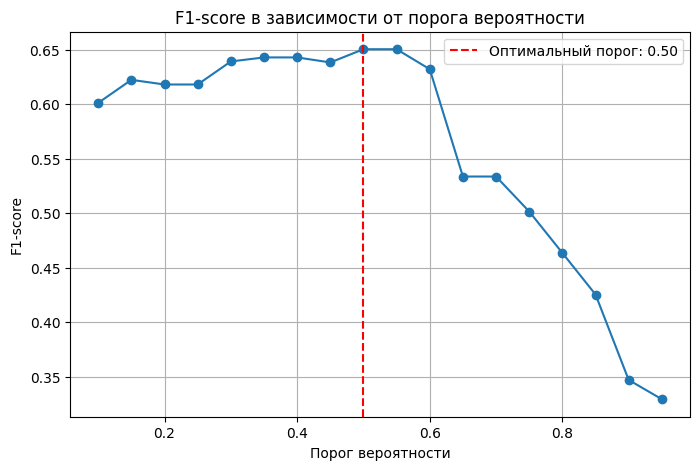

F1-score на тестовой выборке после подбора порога: 0.651


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# Получаем вероятности положительного класса (1)
y_test_proba = pd.Series(tree_pruned.predict_proba(X_test)[:, 1])

# Диапазон порогов
thresholds = np.arange(0.1, 1, 0.05)
scores = []

# Перебираем пороги
for threshold in thresholds:
    y_test_pred_thresh = y_test_proba.apply(lambda x: 1 if x > threshold else 0)
    score = f1_score(y_test, y_test_pred_thresh)
    scores.append(score)

# Находим оптимальный порог
optimal_idx = np.argmax(scores)
optimal_threshold = thresholds[optimal_idx]
optimal_f1 = scores[optimal_idx]

print(f'Оптимальный порог: {optimal_threshold:.2f}')
print(f'F1-score на тестовой выборке при оптимальном пороге: {optimal_f1:.3f}')

# Визуализация
plt.figure(figsize=(8, 5))
plt.plot(thresholds, scores, marker='o')
plt.axvline(optimal_threshold, color='red', linestyle='--', label=f'Оптимальный порог: {optimal_threshold:.2f}')
plt.xlabel('Порог вероятности')
plt.ylabel('F1-score')
plt.title('F1-score в зависимости от порога вероятности')
plt.legend()
plt.grid(True)
plt.show()

# Предсказание классов с оптимальным порогом
y_test_pred_optimal = y_test_proba.apply(lambda x: 1 if x > optimal_threshold else 0)
f1_test_optimal = f1_score(y_test, y_test_pred_optimal)
print(f'F1-score на тестовой выборке после подбора порога: {f1_test_optimal:.3f}')


### Итоговые выводы

* **Максимальный F1 на тесте (0.655)** — логистическая регрессия с полиномиальными признаками и порогом вероятности **0.30**.
* **Pruned Decision Tree (F1 = 0.651)** — лучшая модель среди деревьев; подбор порога не дал прироста (оптимум ≈ 0.5).
* Необрезанное дерево сильно переобучено (F1 train = 1.000, test = 0.527); случайный лес (F1 = 0.645) не превзошёл обрезанное дерево.
* Для демонстрационного прогноза выбрано **обрезанное дерево решений** — проще интерпретировать и применять без масштабирования и настройки порога.
* Обрезанное дерево не переобучено: F1 на train = 0.717, на test = 0.651.


### Прогноз для клиента

Наконец, финальная задача.

У нашего банка есть некоторый клиент, назовём его Василием. В базе данных банка хранятся следующие данные о Василии:

```python
{
    'CreditScore': [601.0],
    'Gender': ['Male'],
    'Age': [42.0],
    'Tenure': [1.0],
    'Balance': [98495.72],
    'NumOfProducts': [1.0],
    'HasCrCard': [1.0],
    'IsActiveMember': [0.0],
    'EstimatedSalary': [40014.76]
}
```

Прогноз вероятности оттока для клиента Василия (обрезанное дерево решений).

> **Примечание.** Учтите, что для предсказания необходимо преобразовать данные к тому формату, на котором обучалась модель, то есть:

* добавить признаки дополнительные признаки; 

* произвести кодирование категориальных признаков;

* произвести масштабирование признаков (если ваша модель обучалась на масштабированных данных) с помощью того же скейлера, который вы использовали при обучении модели;

* сгенерировать полиномиальные признаки.


In [ ]:
import pandas as pd

# Данные Василия
vasiliy_data = {
    'CreditScore': [601.0],
    'Gender': ['Male'],
    'Age': [42.0],
    'Tenure': [1.0],
    'Balance': [98495.72],
    'NumOfProducts': [1.0],
    'HasCrCard': [1.0],
    'IsActiveMember': [0.0],
    'EstimatedSalary': [40014.76]
}

vasiliy_df = pd.DataFrame(vasiliy_data)

# Те же преобразования, что при обучении модели
vasiliy_df['BalanceSalaryRatio'] = vasiliy_df['Balance'] / (vasiliy_df['EstimatedSalary'] + 1e-5)
vasiliy_df['TenureByAge'] = vasiliy_df['Tenure'] / vasiliy_df['Age']
vasiliy_df['CreditScoreGivenAge'] = vasiliy_df['CreditScore'] / vasiliy_df['Age']
vasiliy_df = pd.get_dummies(vasiliy_df, columns=['Gender'], drop_first=True)

missing_cols = set(X_train.columns) - set(vasiliy_df.columns)
for col in missing_cols:
    vasiliy_df[col] = 0

vasiliy_df = vasiliy_df[X_train.columns]

# Прогноз обрезанным деревом решений (F1 = 0.651 на тесте)
prob_exit = tree_pruned.predict_proba(vasiliy_df)[:, 1][0]

print(f"Вероятность того, что Василий уйдет из банка: {prob_exit:.3f}") 

Вероятность того, что Василий уйдет из банка: 0.800
